# 100-window median RPKM profiles (no CI)

Each line shows the median RPKM calculated separately for every window. Real and simulated data are plotted in separate figures. No confidence interval or smoothing is applied.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

BASE = Path('/cta/users/guneyn23')
RPKM_DIR = BASE / 'peak_center_20kb_100w/rpkm'
OUT = RPKM_DIR / 'median_no_ci_plots'
OUT.mkdir(parents=True, exist_ok=True)

REGIONS = ['ATAC', 'H3K9me3', 'H3K27me3']
DAMAGES = ['CPD', '64']
KINDS = ['real', 'sim']
TIMES = ['1m', '15m', '30m', '1h', '4h', '8h']
COLORS = {
    '1m': '#01befe', '15m': '#ffdd00', '30m': '#ff7d00',
    '1h': '#ff006d', '4h': '#adff02', '8h': '#8f00ff',
}

def rpkm_path(region, damage, time, kind):
    folder = 'real' if kind == 'real' else 'simulated'
    return RPKM_DIR / folder / f'{time}_{damage}_{kind}_{region}_100windows_rpkm.bed'


## Calculate the median separately for every window

In [2]:
def medians_by_window(path):
    data = pd.read_csv(
        path,
        sep='\t',
        header=None,
        usecols=[3, 5],
        names=['peak_window', 'rpkm'],
    )
    data['window'] = data['peak_window'].str.rsplit('_', n=1).str[-1].astype(int)
    return data.groupby('window', sort=True)['rpkm'].median().reset_index(name='median_rpkm')

summaries = []

for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            for time in TIMES:
                path = rpkm_path(region, damage, time, kind)
                print('Reading:', path.name)
                table = medians_by_window(path)
                table.insert(0, 'time', time)
                table.insert(0, 'kind', kind)
                table.insert(0, 'damage', damage)
                table.insert(0, 'region', region)
                table['distance_kb'] = -10 + (table['window'] - 0.5) * 0.2
                summaries.append(table)

summary = pd.concat(summaries, ignore_index=True)
summary.to_csv(OUT / '100windows_median_rpkm_no_ci_summary.tsv', sep='\t', index=False)
summary.head()


Reading: 1m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 15m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 30m_CPD_real_ATAC_100windows_rpkm.bed
Reading: 1h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 4h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 8h_CPD_real_ATAC_100windows_rpkm.bed
Reading: 1m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 15m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 30m_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 1h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 4h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 8h_CPD_sim_ATAC_100windows_rpkm.bed
Reading: 1m_64_real_ATAC_100windows_rpkm.bed
Reading: 15m_64_real_ATAC_100windows_rpkm.bed
Reading: 30m_64_real_ATAC_100windows_rpkm.bed
Reading: 1h_64_real_ATAC_100windows_rpkm.bed
Reading: 4h_64_real_ATAC_100windows_rpkm.bed
Reading: 8h_64_real_ATAC_100windows_rpkm.bed
Reading: 1m_64_sim_ATAC_100windows_rpkm.bed
Reading: 15m_64_sim_ATAC_100windows_rpkm.bed
Reading: 30m_64_sim_ATAC_100windows_rpkm.bed
Reading: 1h_64_sim_ATAC_100windows_rpkm.bed


,region,damage,kind,time,window,median_rpkm,distance_kb
0,ATAC,CPD,real,1m,1,0.31,-9.9
1,ATAC,CPD,real,1m,2,0.31,-9.7
2,ATAC,CPD,real,1m,3,0.31,-9.5
3,ATAC,CPD,real,1m,4,0.31,-9.3
4,ATAC,CPD,real,1m,5,0.31,-9.1


## Plot median profiles 


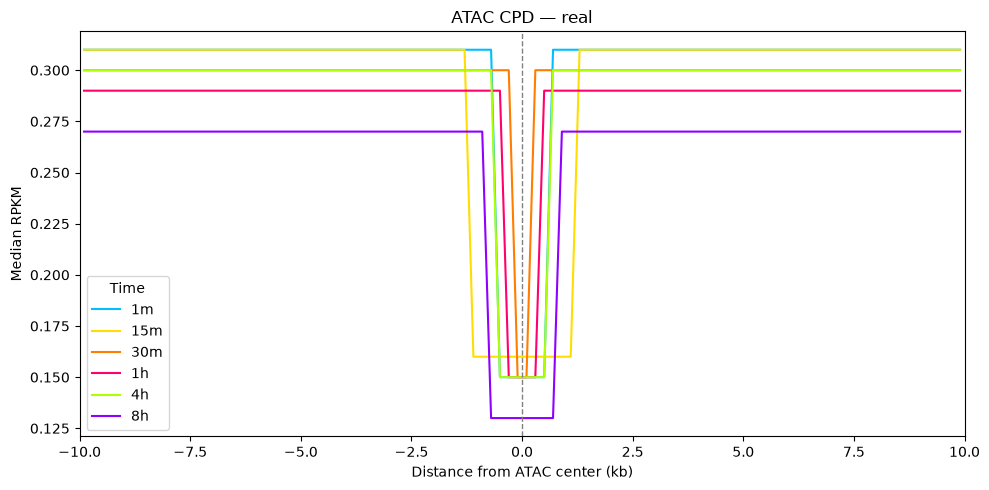

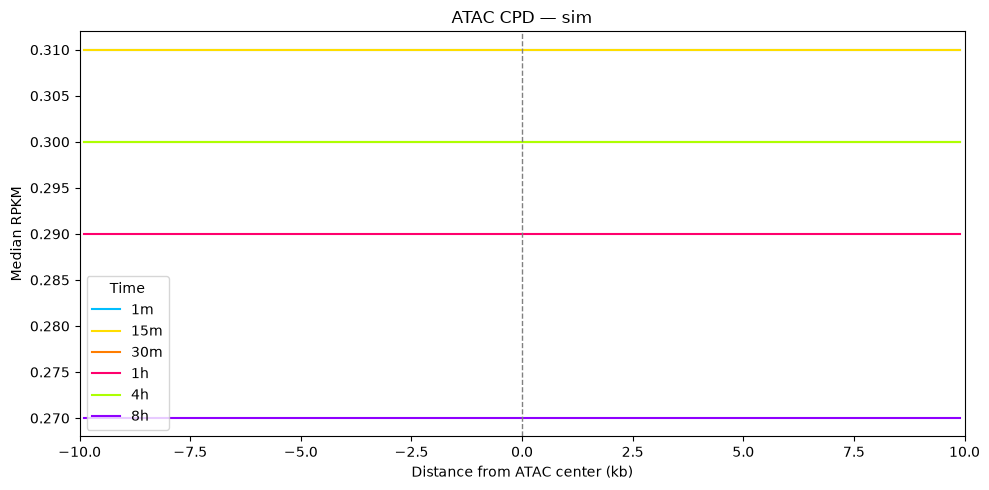

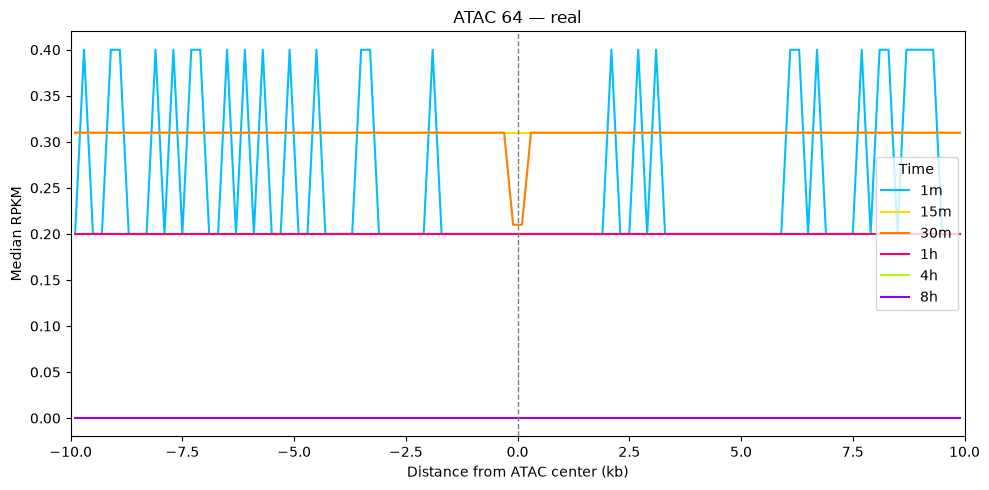

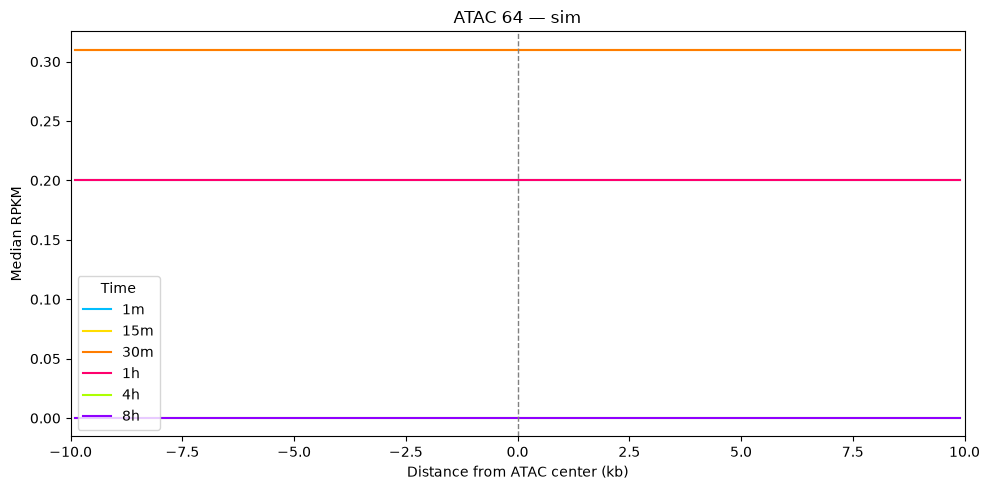

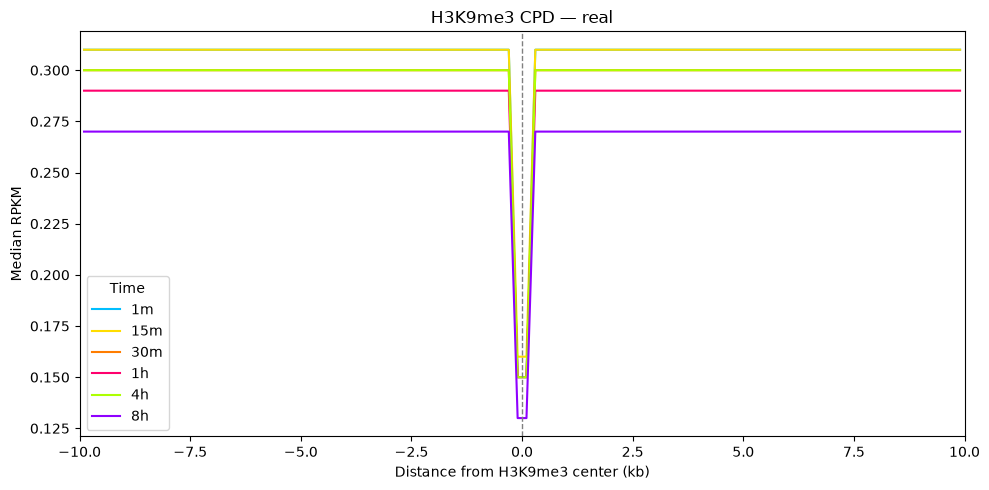

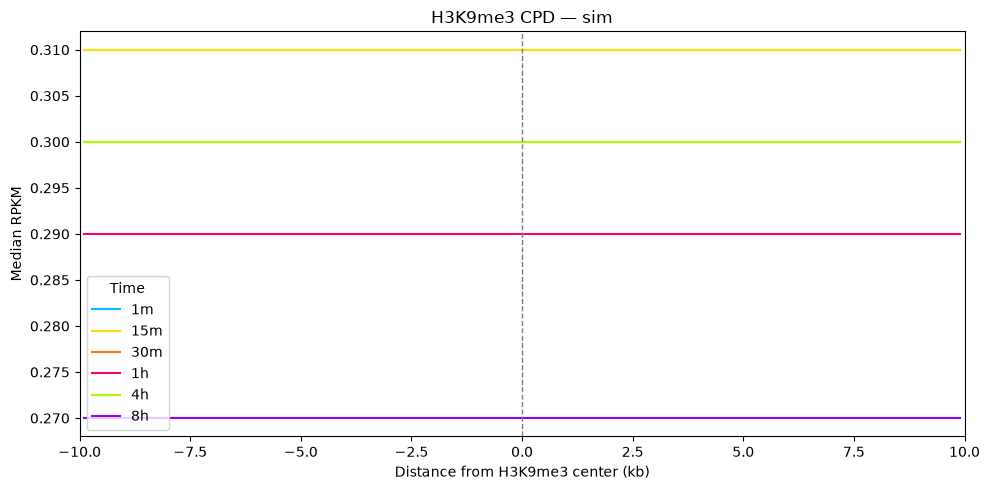

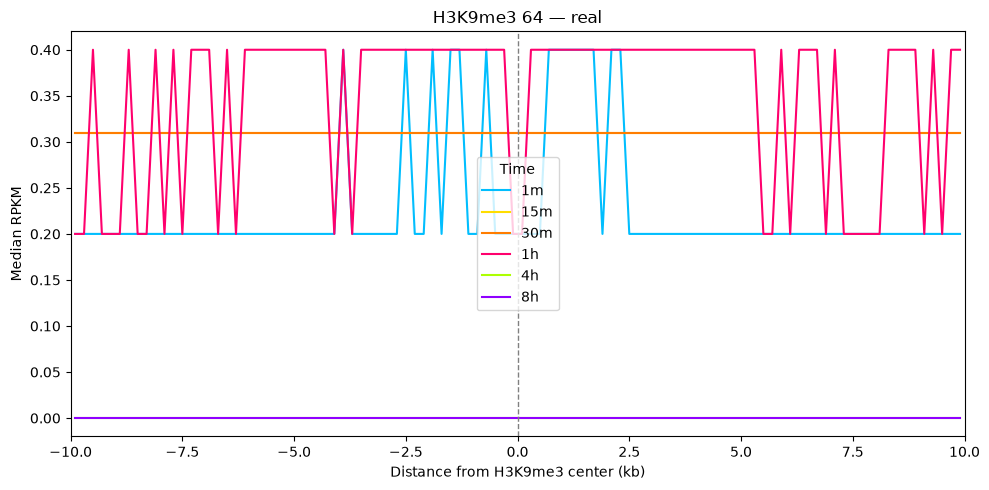

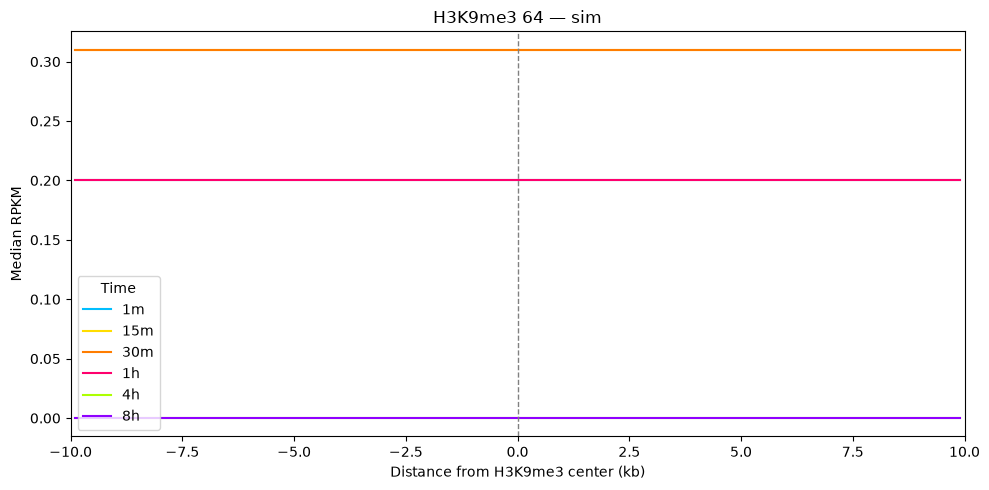

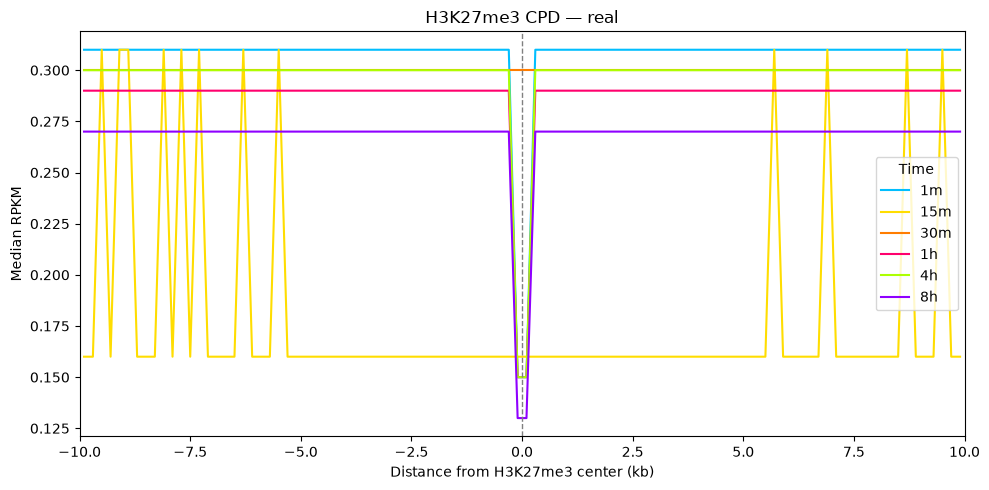

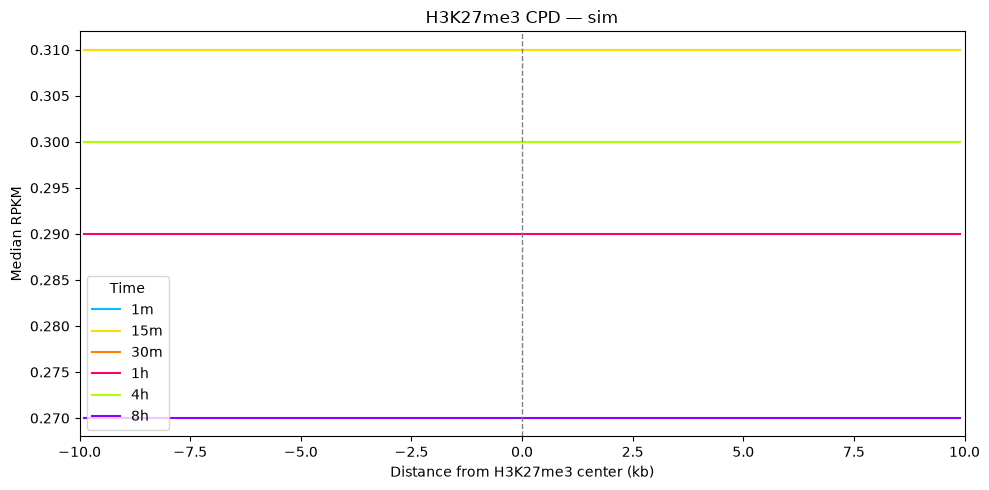

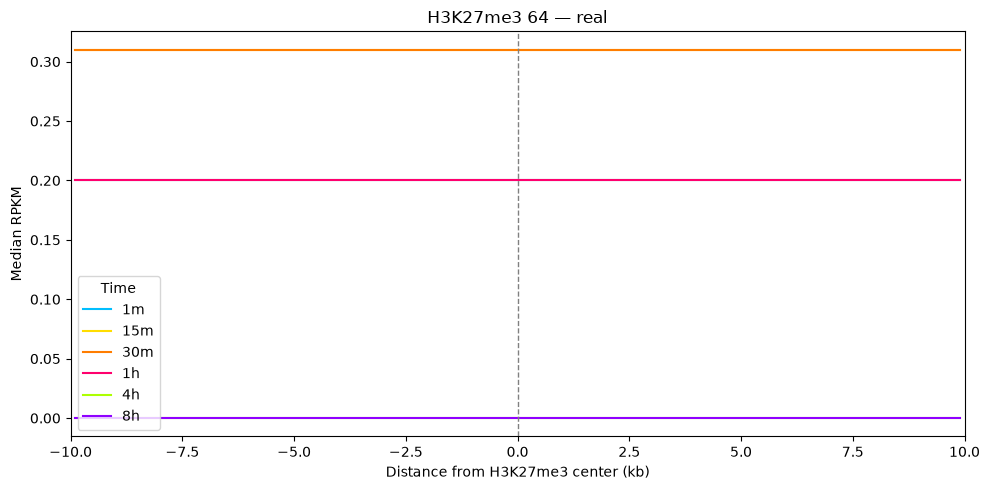

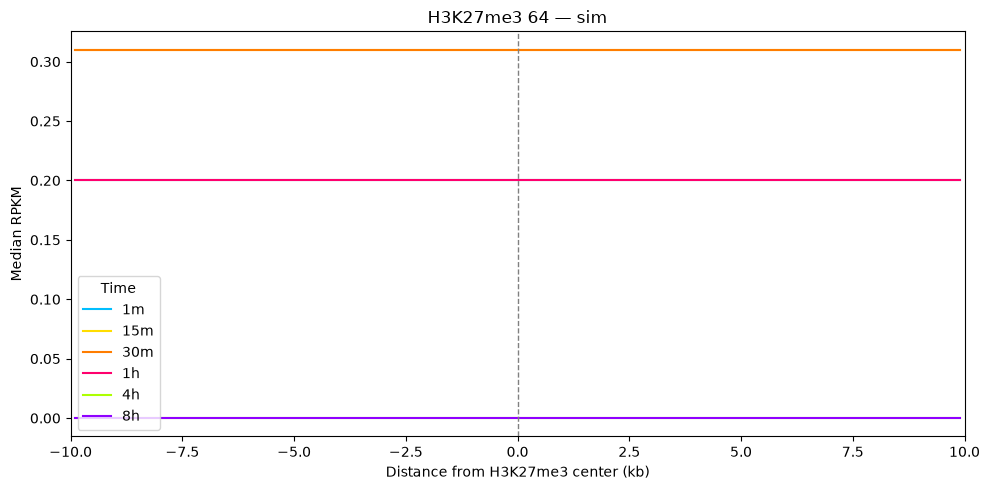

In [3]:
for region in REGIONS:
    for damage in DAMAGES:
        for kind in KINDS:
            selected = summary[
                (summary['region'] == region)
                & (summary['damage'] == damage)
                & (summary['kind'] == kind)
            ]

            fig, ax = plt.subplots(figsize=(10, 5))

            for time in TIMES:
                values = selected[selected['time'] == time].sort_values('window')
                ax.plot(
                    values['distance_kb'],
                    values['median_rpkm'],
                    color=COLORS[time],
                    label=time,
                )

            ax.axvline(0, color='gray', linestyle='--', linewidth=1)
            ax.set_xlim(-10, 10)
            ax.set_xlabel(f'Distance from {region} center (kb)')
            ax.set_ylabel('Median RPKM')
            ax.set_title(f'{region} {damage} — {kind}')
            ax.legend(title='Time')
            fig.tight_layout()
            fig.savefig(
                OUT / f'{region}_{damage}_{kind}_median_rpkm_no_ci.png',
                dpi=300,
                bbox_inches='tight',
            )
            plt.show()
            plt.close(fig)
